# Лабораторная работа "Пороговый детектор на заданной полосе частот"

*Выполнила*: Пелсе Александра (506841). Речевые технологии и машинное бучение, 1 курс, семестр 2. 2026 год.

*Задание*: разрезать “Стрельба на улице.wav” по 1 секунде.

Реализовать пороговый классификатор который определит: на каких интервалах есть выстрел, а на каких нет

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

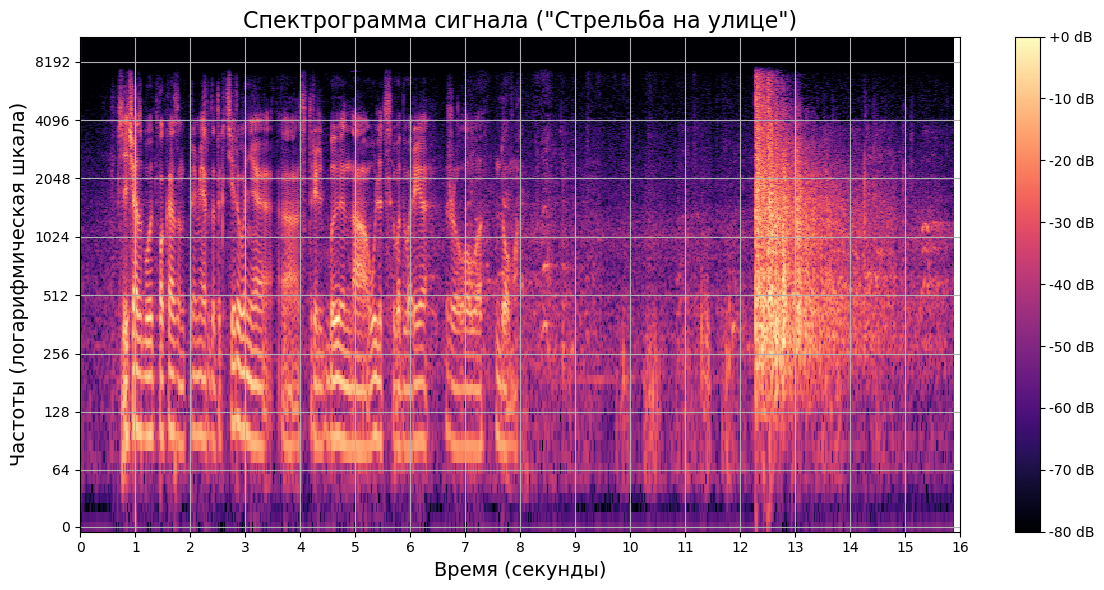

In [2]:
def create_specshow_wav(file_name):
    y, sr = librosa.load(file_name)

    # Длительность записи в секундах (округлим вверх)
    duration_seconds = int(np.ceil(len(y)/sr))

    # Получим спектрограммы сигнала
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Создадим график
    fig, ax = plt.subplots(figsize=(12, 6))
    img = librosa.display.specshow(S_db, x_axis='time', y_axis='log', sr=sr, ax=ax)

    # Динамическое определение количества делений на оси X
    ticks = list(range(duration_seconds + 1))  # +1, чтобы включить последнюю полную секунду
    labels = [f"{i}" for i in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels)

    # Подписываем оси
    ax.set_xlabel('Время (секунды)', fontsize=14)
    ax.set_ylabel('Частоты (логарифмическая шкала)', fontsize=14)
    ax.set_title('Спектрограмма сигнала ("Стрельба на улице")', fontsize=16)

    # Показываем сетку и легенду
    plt.grid(True)
    plt.colorbar(img, format="%+2.f dB")
    plt.tight_layout()  # Оптимизация расположения элементов графика
    plt.show()

create_specshow_wav('Стрельба на улице.wav')

### Построение классификатора

Пороговое значение подбираем экспериментально

In [3]:
def check_shooting_in_wav(file_name):
    y, sr = librosa.load(file_name)

    # Параметры анализа окон
    window_size = int(sr * 1)   # Окно длиной в одну секунду
    step_size = window_size     # Смещение окна также равно длине окна
    n_windows = len(y) // step_size + 1  # Количество окон

    # Диапазон частот (Гц), в котором ожидаем услышать характерные звуки выстрелов
    low_freq = 200  # Нижняя граница диапазона
    high_freq = 8000  # Верхняя граница диапазона

    # Список для хранения результатов классификации
    shot_detected = []

    for i in range(n_windows):
        start_idx = i * step_size
        end_idx = min(start_idx + window_size, len(y))
    
        if end_idx > start_idx:
            segment = y[start_idx:end_idx]
        
            # Применяем FFT к сегменту
            spectrum = np.abs(np.fft.rfft(segment))
            freqs_segment = np.linspace(0, sr / 2, len(spectrum))
        
            # Суммируем энергию в заданном диапазоне частот
            # Чем больше энергии содержится в сигнале, тем вероятнее, что это звук выстрела
            energy_in_range = sum(spectrum[(freqs_segment >= low_freq) & (freqs_segment <= high_freq)])
        
            # Пороговое значение энергии сигнала
            threshold = 50000  # значение подобрано экспериментально
        
            # Классификация: наличие выстрела или нет
            shot_detected.append((start_idx/sr, energy_in_range > threshold))

    # Результаты отображаются как список пар (начало сегмента, найден выстрел или нет).
    print("Интервалы с обнаруженным выстрелом:")
    for t_start, detected in shot_detected:
        print(f"Время начала {t_start:.2f}, обнаружен выстрел: {detected}")

check_shooting_in_wav('Стрельба на улице.wav')

Интервалы с обнаруженным выстрелом:
Время начала 0.00, обнаружен выстрел: False
Время начала 1.00, обнаружен выстрел: False
Время начала 2.00, обнаружен выстрел: False
Время начала 3.00, обнаружен выстрел: False
Время начала 4.00, обнаружен выстрел: False
Время начала 5.00, обнаружен выстрел: False
Время начала 6.00, обнаружен выстрел: False
Время начала 7.00, обнаружен выстрел: False
Время начала 8.00, обнаружен выстрел: False
Время начала 9.00, обнаружен выстрел: False
Время начала 10.00, обнаружен выстрел: False
Время начала 11.00, обнаружен выстрел: False
Время начала 12.00, обнаружен выстрел: True
Время начала 13.00, обнаружен выстрел: False
Время начала 14.00, обнаружен выстрел: False
Время начала 15.00, обнаружен выстрел: False


### Проверим найденное значение на других wav записях

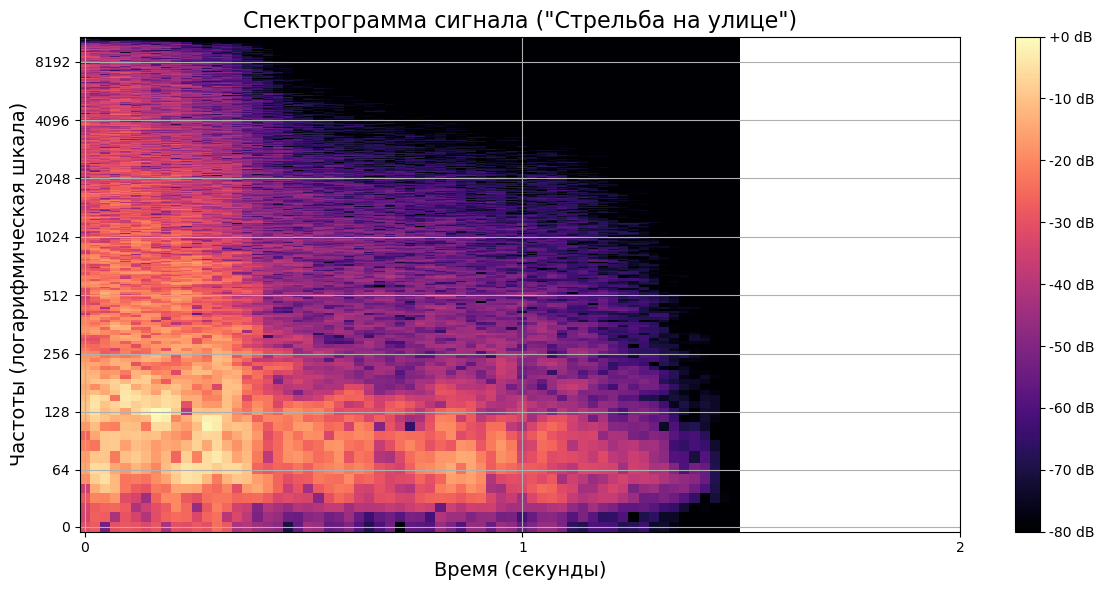

Интервалы с обнаруженным выстрелом:
Время начала 0.00, обнаружен выстрел: True
Время начала 1.00, обнаружен выстрел: False


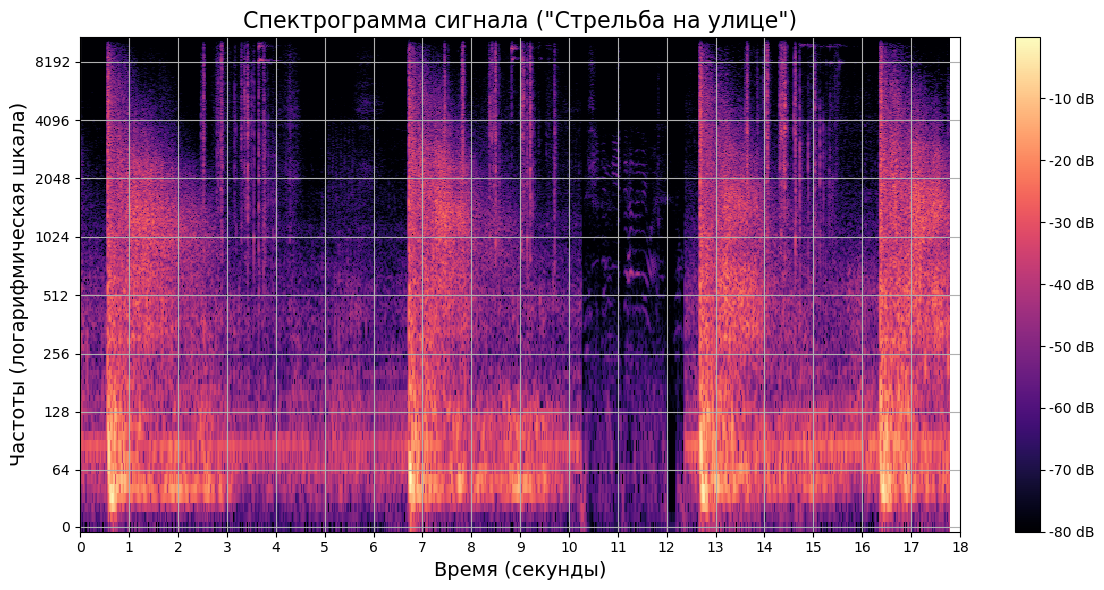

Интервалы с обнаруженным выстрелом:
Время начала 0.00, обнаружен выстрел: True
Время начала 1.00, обнаружен выстрел: True
Время начала 2.00, обнаружен выстрел: False
Время начала 3.00, обнаружен выстрел: False
Время начала 4.00, обнаружен выстрел: False
Время начала 5.00, обнаружен выстрел: False
Время начала 6.00, обнаружен выстрел: True
Время начала 7.00, обнаружен выстрел: True
Время начала 8.00, обнаружен выстрел: False
Время начала 9.00, обнаружен выстрел: False
Время начала 10.00, обнаружен выстрел: False
Время начала 11.00, обнаружен выстрел: False
Время начала 12.00, обнаружен выстрел: True
Время начала 13.00, обнаружен выстрел: True
Время начала 14.00, обнаружен выстрел: True
Время начала 15.00, обнаружен выстрел: False
Время начала 16.00, обнаружен выстрел: True
Время начала 17.00, обнаружен выстрел: True


In [4]:
create_specshow_wav('a-clear-short-shot-from-a-machine-gun-in-a-tunnel.wav')
check_shooting_in_wav('a-clear-short-shot-from-a-machine-gun-in-a-tunnel.wav')

create_specshow_wav('z_uk-vystrel-iz-_into_ki.wav')
check_shooting_in_wav('z_uk-vystrel-iz-_into_ki.wav')

## Итоги: 

пороговое значение энергии сигнала подобрано экспериментально. Составляет 50000. Классификатор протестиован на двух записях. Найденное пороговое значение подобрано верно.